## Ridge Regression for MonthlyCharges

In [20]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import learning_curve
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


## Load and inspect the data

In [21]:
df= pd.read_csv("data/telco-churn.csv")
df.shape

(7043, 21)

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [24]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,"7,043.0000",NaN,NaN,NaN,0.1621,0.3686,0.0000,0.0000,0.0000,0.0000,1.0000
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,"7,043.0000",NaN,NaN,NaN,32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [25]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank / invalid TotalCharges rows:", df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

print("Total missing values after cleaning:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Blank / invalid TotalCharges rows: 11
Total missing values after cleaning: 0
Duplicate rows: 0


## Exploratory Data Analysis(EDA)

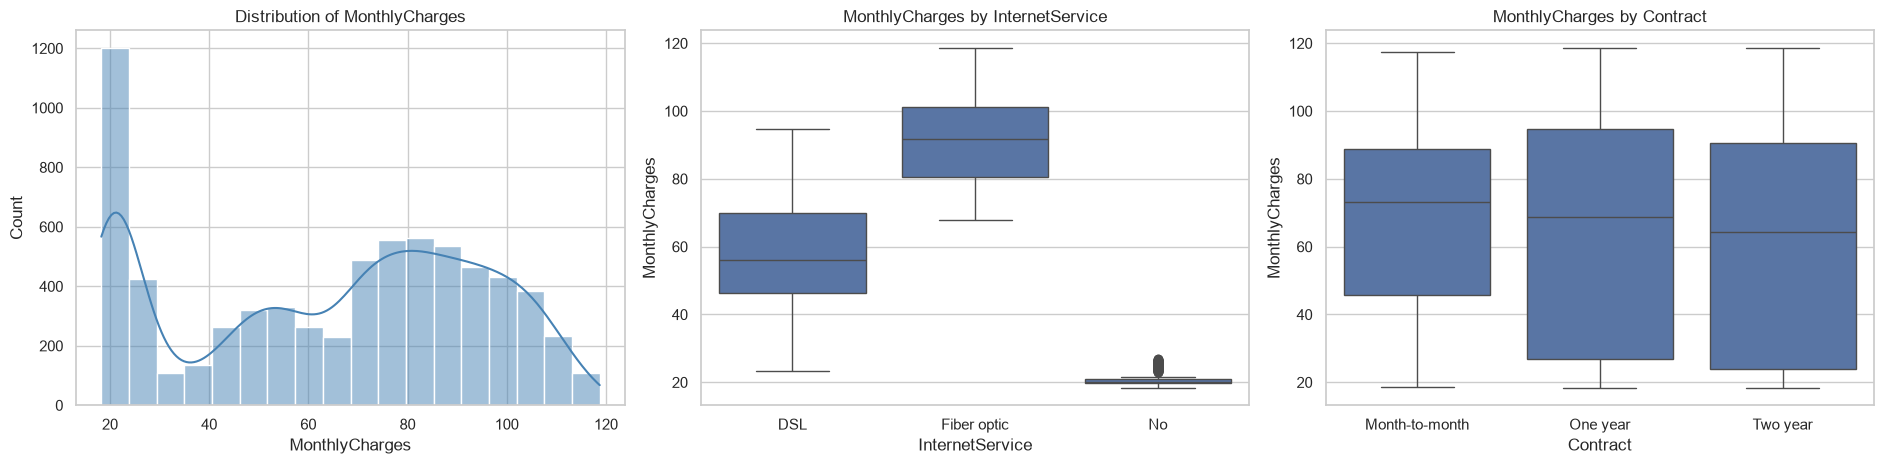

count   7,043.0000
mean       64.7617
std        30.0900
min        18.2500
25%        35.5000
50%        70.3500
75%        89.8500
max       118.7500
Name: MonthlyCharges, dtype: float64


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of MonthlyCharges")
sns.boxplot(data=df, x="InternetService", y='MonthlyCharges', ax=axes[1])
axes[1].set_title("MonthlyCharges by InternetService")
sns.boxplot(data=df, x="Contract", y='MonthlyCharges', ax=axes[2])
axes[2].set_title("MonthlyCharges by Contract")
plt.tight_layout()
plt.show()

print(df['MonthlyCharges'].describe())

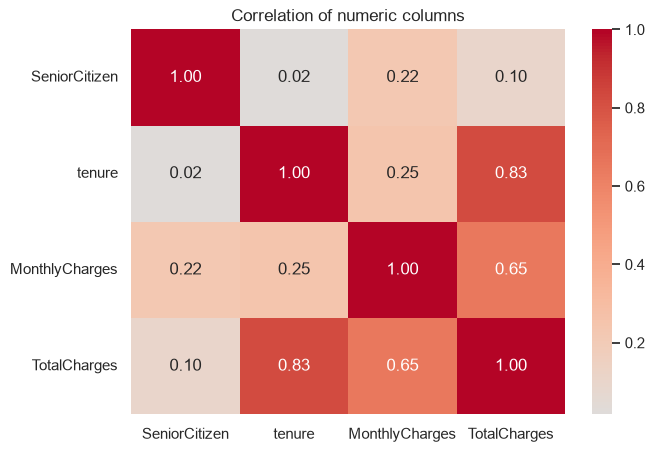

corr(TotalCharges, tenure x MonthlyCharges) = 0.9996


In [27]:
numeric_raw = df.select_dtypes(include="number")
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_raw.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of numeric columns")
plt.show()

# Is TotalCharges basically the target in disguise?
leak_corr = np.corrcoef(df["TotalCharges"], df["tenure"] * df["MonthlyCharges"])[0, 1]
print(f"corr(TotalCharges, tenure x MonthlyCharges) = {leak_corr:.4f}")

## Feature Engineering

In [28]:
def engineer_features(data):
    d = data.copy()
    d = d.drop(columns=["customerID"], errors="ignore")
    # Harmonise duplicate labels
    addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]
    d[addon_cols] = d[addon_cols].replace("No internet service", "No")
    d["MultipleLines"] = d["MultipleLines"].replace("No phone service", "No")

    # counts
    d["num_addons"] = (d[addon_cols] == "Yes").sum(axis=1)
    d["num_streaming"] = (d[["StreamingTV", "StreamingMovies"]] == "Yes").sum(axis=1)
    d["num_protection"] = (d[["OnlineSecurity", "OnlineBackup","DeviceProtection", "TechSupport"]] == "Yes").sum(axis=1)

    #Binary flags
    d["has_internet"] = (d["InternetService"] != "No").astype(int)
    d["is_fiber"] = (d["InternetService"] == "Fiber optic").astype(int)
    d["has_phone"] = (d["PhoneService"] == "Yes").astype(int)
    d["multiple_lines_flag"] = (d["MultipleLines"] == "Yes").astype(int)
    d["total_services"] = (d["num_addons"] + d["has_internet"]+ d["has_phone"] + d["multiple_lines_flag"])
    d["auto_pay"] = d["PaymentMethod"].str.contains("automatic", case=False).astype(int)
    d["is_month_to_month"] = (d["Contract"] == "Month-to-month").astype(int)
    d["has_family"] = ((d["Partner"] == "Yes") | (d["Dependents"] == "Yes")).astype(int)

    # Tenure transformations
    d["log_tenure"] = np.log1p(d["tenure"])
    d["tenure_sq"] = d["tenure"] ** 2
    d["tenure_group"] = pd.cut(d["tenure"], bins=[-1, 12, 24, 48, 60, np.inf],
    labels=["0-12", "13-24", "25-48", "49-60", "61+"]).astype(str)

    #Leakage control
    if not False:
        d = d.drop(columns=["TotalCharges"], errors="ignore")
    return d


X_all = engineer_features(df.drop(columns=['MonthlyCharges']))
y = df['MonthlyCharges']
print("Feature matrix shape:", X_all.shape)
X_all.head()

Feature matrix shape: (7043, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,num_addons,num_streaming,num_protection,has_internet,is_fiber,has_phone,multiple_lines_flag,total_services,auto_pay,is_month_to_month,has_family,log_tenure,tenure_sq,tenure_group
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,1,0,1,1,0,0,0,2,0,1,1,0.6931,1,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,2,0,2,1,0,1,0,4,0,0,0,3.5553,1156,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,2,0,2,1,0,1,0,4,0,1,0,1.0986,4,0-12
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,3,0,3,1,0,0,0,4,1,0,0,3.8286,2025,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,0,0,0,1,1,1,0,2,0,1,0,1.0986,4,0-12


In [29]:
new_feats = ["num_addons", "num_streaming", "num_protection", "total_services","has_internet", "is_fiber", "has_phone", "multiple_lines_flag",
"auto_pay", "is_month_to_month", "has_family", "log_tenure", "tenure_sq"]
corr_with_target = (pd.concat([X_all[new_feats], y], axis=1)
.corr()['MonthlyCharges'].drop('MonthlyCharges').sort_values(ascending=False))
corr_with_target.to_frame("corr with MonthlyCharges")

,corr with MonthlyCharges
total_services,0.8514
is_fiber,0.7871
has_internet,0.7636
num_addons,0.7247
num_streaming,0.7179
num_protection,0.5649
multiple_lines_flag,0.4904
has_phone,0.2474
log_tenure,0.2397
tenure_sq,0.2382


## Train/test split and preprocessing

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.3, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)
print(f"Target mean  train={y_train.mean():.2f}  test={y_test.mean():.2f}")

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
print("\nNumeric features    :", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)


def make_preprocessor(scale=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(num_steps)
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])


def clean_names(names):
    return [n.split("__", 1)[1] for n in names]

Train: (4930, 32)  Test: (2113, 32)
Target mean  train=64.80  test=64.68

Numeric features    : 15 ['SeniorCitizen', 'tenure', 'num_addons', 'num_streaming', 'num_protection', 'has_internet', 'is_fiber', 'has_phone', 'multiple_lines_flag', 'total_services', 'auto_pay', 'is_month_to_month', 'has_family', 'log_tenure', 'tenure_sq']
Categorical features: 17 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'tenure_group']


## Evaluation Helpers

In [31]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


In [32]:
def evaluate(y_true, y_pred, n_features, label):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mse = mean_squared_error(y_true, y_pred)
    return {"Dataset": label,"MAE": mean_absolute_error(y_true, y_pred),"MSE": mse,"RMSE": np.sqrt(mse),"R2": r2,"Adj_R2": adj_r2,"MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100}


def error_table(model, name, n_features):
    rows = []
    for label, X_, y_ in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        row = evaluate(y_, model.predict(X_), n_features, label)
        row["Model"] = name
        rows.append(row)
    return pd.DataFrame(rows)[["Model", "Dataset", "MAE", "MSE", "RMSE", "R2", "Adj_R2", "MAPE_%"]]


def cv_report(model, name, X=None, y_=None):
    X = X_train if X is None else X
    y_ = y_train if y_ is None else y_
    s = cross_validate(model, X, y_, cv=cv, n_jobs=-1, return_train_score=True,
                       scoring={"mae": "neg_mean_absolute_error",
                                "rmse": "neg_root_mean_squared_error",
                                "r2": "r2"})
    out = pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R2"],
        "CV train (mean)": [-s["train_mae"].mean(), -s["train_rmse"].mean(), s["train_r2"].mean()],
        "CV validation (mean)": [-s["test_mae"].mean(), -s["test_rmse"].mean(), s["test_r2"].mean()],
        "CV validation (std)": [s["test_mae"].std(), s["test_rmse"].std(), s["test_r2"].std()],
    })
    print(f"5-fold cross-validation on the training set - {name}")
    return out


def diagnostic_plots(y_true, y_pred, title):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    resid = y_true - y_pred
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))

    ax[0, 0].scatter(y_true, y_pred, alpha=0.4, s=14)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax[0, 0].plot(lims, lims, "r--")
    ax[0, 0].set(xlabel="Actual MonthlyCharges", ylabel="Predicted", title="Actual vs predicted")

    ax[0, 1].scatter(y_pred, resid, alpha=0.4, s=14)
    ax[0, 1].axhline(0, color="r", ls="--")
    ax[0, 1].set(xlabel="Predicted", ylabel="Residual (actual - predicted)", title="Residuals vs predicted")

    sns.histplot(resid, kde=True, ax=ax[1, 0], color="seagreen")
    ax[1, 0].set(xlabel="Residual", title="Residual distribution")

    stats.probplot(resid, dist="norm", plot=ax[1, 1])
    ax[1, 1].set_title("Q-Q plot of residuals")

    fig.suptitle(title, fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()


def worst_predictions(model, X_, y_, n=10):
    out = X_.copy()
    out["actual"] = y_.values
    out["predicted"] = model.predict(X_)
    out["abs_error"] = (out["actual"] - out["predicted"]).abs()
    cols = ["actual", "predicted", "abs_error", "InternetService", "Contract", "num_addons", "tenure"]
    return out.nlargest(n, "abs_error")[cols]


def coef_plot(names, coefs, title, top=15):
    s = pd.Series(coefs, index=names)
    top_s = s.reindex(s.abs().sort_values(ascending=False).head(top).index).sort_values()
    plt.figure(figsize=(9, 6))
    colors = ["tomato" if v < 0 else "steelblue" for v in top_s.values]
    plt.barh(top_s.index, top_s.values, color=colors)
    plt.axvline(0, color="k", lw=0.8)
    plt.title(title)
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

## Refrence Model (Linear Regression)

In [33]:
ols_pipe = Pipeline([("prep", make_preprocessor()),
                     ("model", LinearRegression())]).fit(X_train, y_train)
n_feat = ols_pipe.named_steps["prep"].get_feature_names_out().shape[0]
print("Input features after encoding:", n_feat)
error_table(ols_pipe, "Linear Regression", n_feat)

Input features after encoding: 43


,Model,Dataset,MAE,MSE,RMSE,R2,Adj_R2,MAPE_%
0,Linear Regression,Train,0.7748,1.0232,1.0115,0.9989,0.9989,1.3941
1,Linear Regression,Test,0.7956,1.1118,1.0544,0.9988,0.9987,1.3870


## Ridge Regression with cross- validated alpha

In [34]:
ridge_pipe = Pipeline([("prep", make_preprocessor()),
    ("model", Ridge(random_state=42))])

param_grid = {"model__alpha": np.logspace(-3, 3, 40)}

grid = GridSearchCV(ridge_pipe, param_grid, cv=cv,scoring="neg_root_mean_squared_error",
return_train_score=True, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

best_alpha = grid.best_params_["model__alpha"]
print(f"Best alpha        : {best_alpha:.5f}")
print(f"Best CV RMSE      : {-grid.best_score_:.4f}")

Best alpha        : 1.70125
Best CV RMSE      : 1.0169


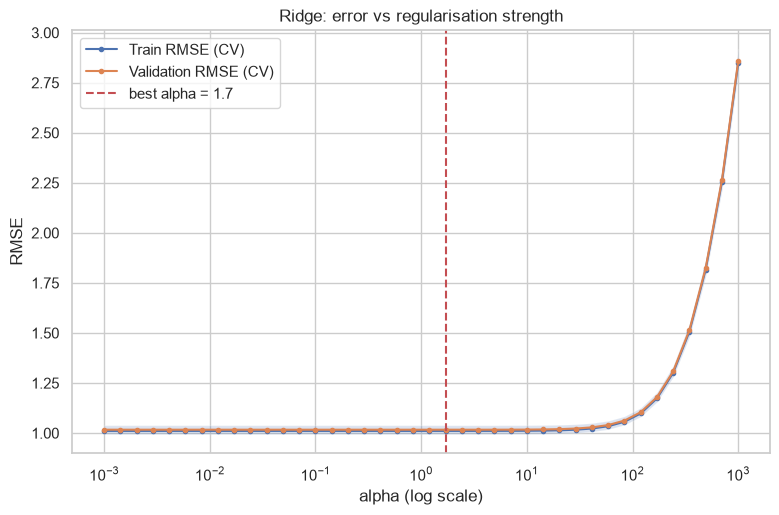

In [35]:
cvres = pd.DataFrame(grid.cv_results_)
alphas = cvres["param_model__alpha"].astype(float)
val_rmse = -cvres["mean_test_score"]
val_std = cvres["std_test_score"]
tr_rmse = -cvres["mean_train_score"]

plt.figure(figsize=(9, 5.5))
plt.plot(alphas, tr_rmse, label="Train RMSE (CV)", marker="o", ms=3)
plt.plot(alphas, val_rmse, label="Validation RMSE (CV)", marker="o", ms=3)
plt.fill_between(alphas, val_rmse - val_std, val_rmse + val_std, alpha=0.2)
plt.axvline(best_alpha, color="r", ls="--", label=f"best alpha = {best_alpha:.3g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("RMSE")
plt.title("Ridge: error vs regularisation strength")
plt.legend()
plt.show()

**Reading the curve:** with small `alpha` the model is close to OLS; as `alpha` grows, validation error first stays flat or improves slightly and then rises once the penalty starts to under-fit. The red line marks the best compromise.

## Coefficient shrinkage path

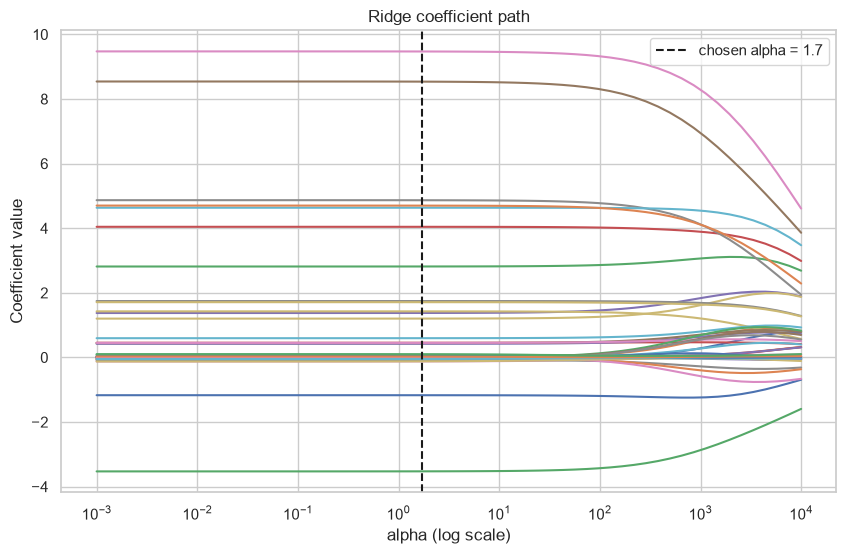

In [36]:
prep_path = make_preprocessor().fit(X_train)
Xtr_t = prep_path.transform(X_train)
feat_names = clean_names(prep_path.get_feature_names_out())

alphas_path = np.logspace(-3, 4, 60)
coef_path = np.array([Ridge(alpha=a).fit(Xtr_t, y_train).coef_ for a in alphas_path])

plt.figure(figsize=(10, 6))
plt.plot(alphas_path, coef_path)
plt.axvline(best_alpha, color="k", ls="--", label=f"chosen alpha = {best_alpha:.3g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Ridge coefficient path")
plt.legend()
plt.show()

## Final Model: errros, diagnostics, and interpretation

In [37]:
best_ridge = grid.best_estimator_
results = pd.concat([error_table(ols_pipe, "Linear Regression", n_feat),
error_table(best_ridge, f"Ridge (alpha={best_alpha:.3g})", n_feat)],
ignore_index=True)
results

,Model,Dataset,MAE,MSE,RMSE,R2,Adj_R2,MAPE_%
0,Linear Regression,Train,0.7748,1.0232,1.0115,0.9989,0.9989,1.3941
1,Linear Regression,Test,0.7956,1.1118,1.0544,0.9988,0.9987,1.3870
2,Ridge (alpha=1.7),Train,0.7748,1.0232,1.0115,0.9989,0.9989,1.3942
3,Ridge (alpha=1.7),Test,0.7956,1.1119,1.0545,0.9988,0.9987,1.3873


In [38]:
cv_report(best_ridge, "Ridge")

5-fold cross-validation on the training set - Ridge


,Metric,CV train (mean),CV validation (mean),CV validation (std)
0,MAE,0.7743,0.7794,0.0146
1,RMSE,1.0109,1.0169,0.0222
2,R2,0.9989,0.9989,0.0001


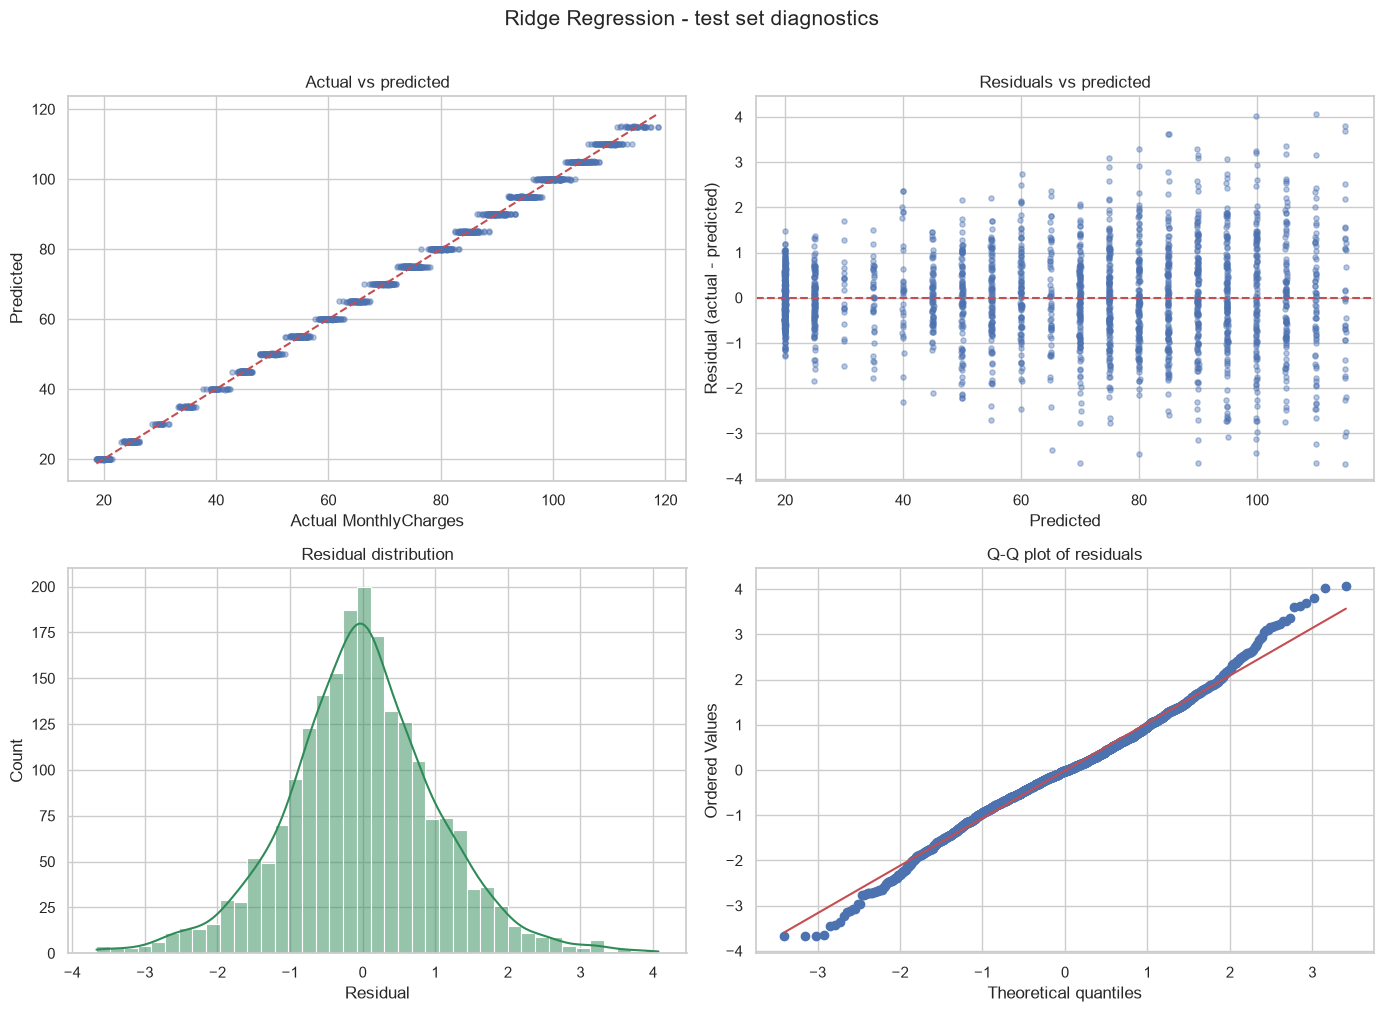

In [39]:
diagnostic_plots(y_test, best_ridge.predict(X_test), "Ridge Regression - test set diagnostics")

## Learming Curve 

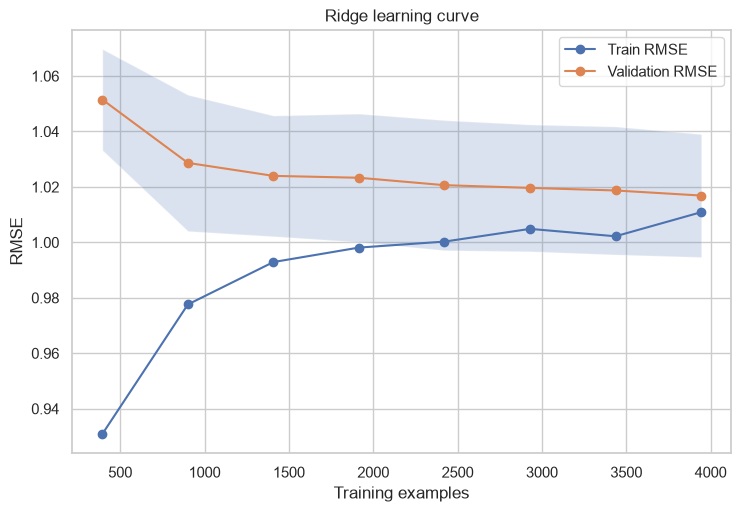

In [40]:
sizes, tr_sc, va_sc = learning_curve(
    best_ridge, X_train, y_train, cv=cv, n_jobs=-1,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, shuffle=True)

plt.figure(figsize=(8.5, 5.5))
plt.plot(sizes, -tr_sc.mean(axis=1), "o-", label="Train RMSE")
plt.plot(sizes, -va_sc.mean(axis=1), "o-", label="Validation RMSE")
plt.fill_between(sizes, -va_sc.mean(axis=1) - va_sc.std(axis=1),-va_sc.mean(axis=1) + va_sc.std(axis=1), alpha=0.2)
plt.xlabel("Training examples")
plt.ylabel("RMSE")
plt.title("Ridge learning curve")
plt.legend()
plt.show()

## Ridge vs OLS coefficients

,feature,OLS,Ridge
1,tenure,-0.0332,-0.0244
38,tenure_group_0-12,-0.1269,-0.1225
5,has_internet,8.5418,8.5375
14,tenure_sq,0.0086,0.0044
42,tenure_group_61+,0.1002,0.0972
41,tenure_group_49-60,0.0310,0.0283
6,is_fiber,9.4737,9.4710
37,Churn_Yes,-0.0507,-0.0480
32,PaperlessBilling_Yes,-0.0032,-0.0008
39,tenure_group_13-24,-0.0513,-0.0490


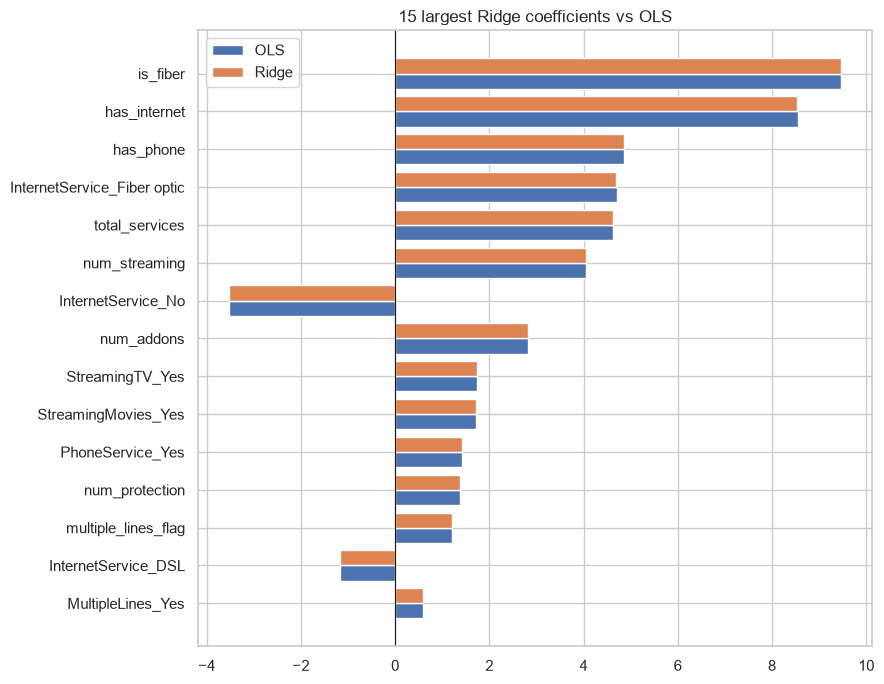

In [41]:
names = clean_names(best_ridge.named_steps["prep"].get_feature_names_out())
cmp_df = pd.DataFrame({"feature": names,
"OLS": ols_pipe.named_steps["model"].coef_,
"Ridge": best_ridge.named_steps["model"].coef_})
cmp_df["abs_diff"] = (cmp_df["OLS"] - cmp_df["Ridge"]).abs()
display(cmp_df.sort_values("abs_diff", ascending=False).head(15).drop(columns="abs_diff"))

top = cmp_df.reindex(cmp_df["Ridge"].abs().sort_values(ascending=False).head(15).index).iloc[::-1]
pos = np.arange(len(top))
plt.figure(figsize=(9, 7))
plt.barh(pos - 0.2, top["OLS"], height=0.4, label="OLS")
plt.barh(pos + 0.2, top["Ridge"], height=0.4, label="Ridge")
plt.yticks(pos, top["feature"])
plt.axvline(0, color="k", lw=0.8)
plt.title("15 largest Ridge coefficients vs OLS")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
worst_predictions(best_ridge, X_test, y_test, n=10)

,actual,predicted,abs_error,InternetService,Contract,num_addons,tenure
3856,114.1000,110.0266,4.0734,Fiber optic,Month-to-month,5,61
5190,103.9500,99.9360,4.0140,Fiber optic,Month-to-month,3,29
4586,118.7500,114.9439,3.8061,Fiber optic,Two year,6,72
2115,118.6500,114.9631,3.6869,Fiber optic,Two year,6,71
6859,111.3000,114.9656,3.6656,Fiber optic,Two year,6,71
5478,106.3000,109.9634,3.6634,Fiber optic,Two year,6,52
4715,86.4000,90.0630,3.6630,DSL,Two year,6,64
1844,66.4000,70.0532,3.6532,DSL,One year,4,59
5010,88.6500,85.0331,3.6169,DSL,Two year,5,61
487,88.6000,84.9900,3.6100,DSL,Two year,5,72
